📤 Please select an image to upload:


Saving Gemini_Generated_Image_ivkdativkdativkd.png to Gemini_Generated_Image_ivkdativkdativkd.png

OBJECT COUNTING & MEASUREMENT RESULTS
 Total Objects Detected: 5

📦 Object  1 | Area: 265450.50 px² | Perimeter: 2372.36 px | BBox: 553x518 px | Centroid: (389, 1403)
📦 Object  2 | Area: 163533.00 px² | Perimeter: 2230.08 px | BBox: 620x467 px | Centroid: (1785, 1020)
📦 Object  3 | Area: 173060.00 px² | Perimeter: 2055.93 px | BBox: 520x462 px | Centroid: (1103, 734)
📦 Object  4 | Area: 255047.00 px² | Perimeter: 2307.92 px | BBox: 725x374 px | Centroid: (1722, 417)
📦 Object  5 | Area: 154849.00 px² | Perimeter: 1851.89 px | BBox: 565x491 px | Centroid: (382, 510)


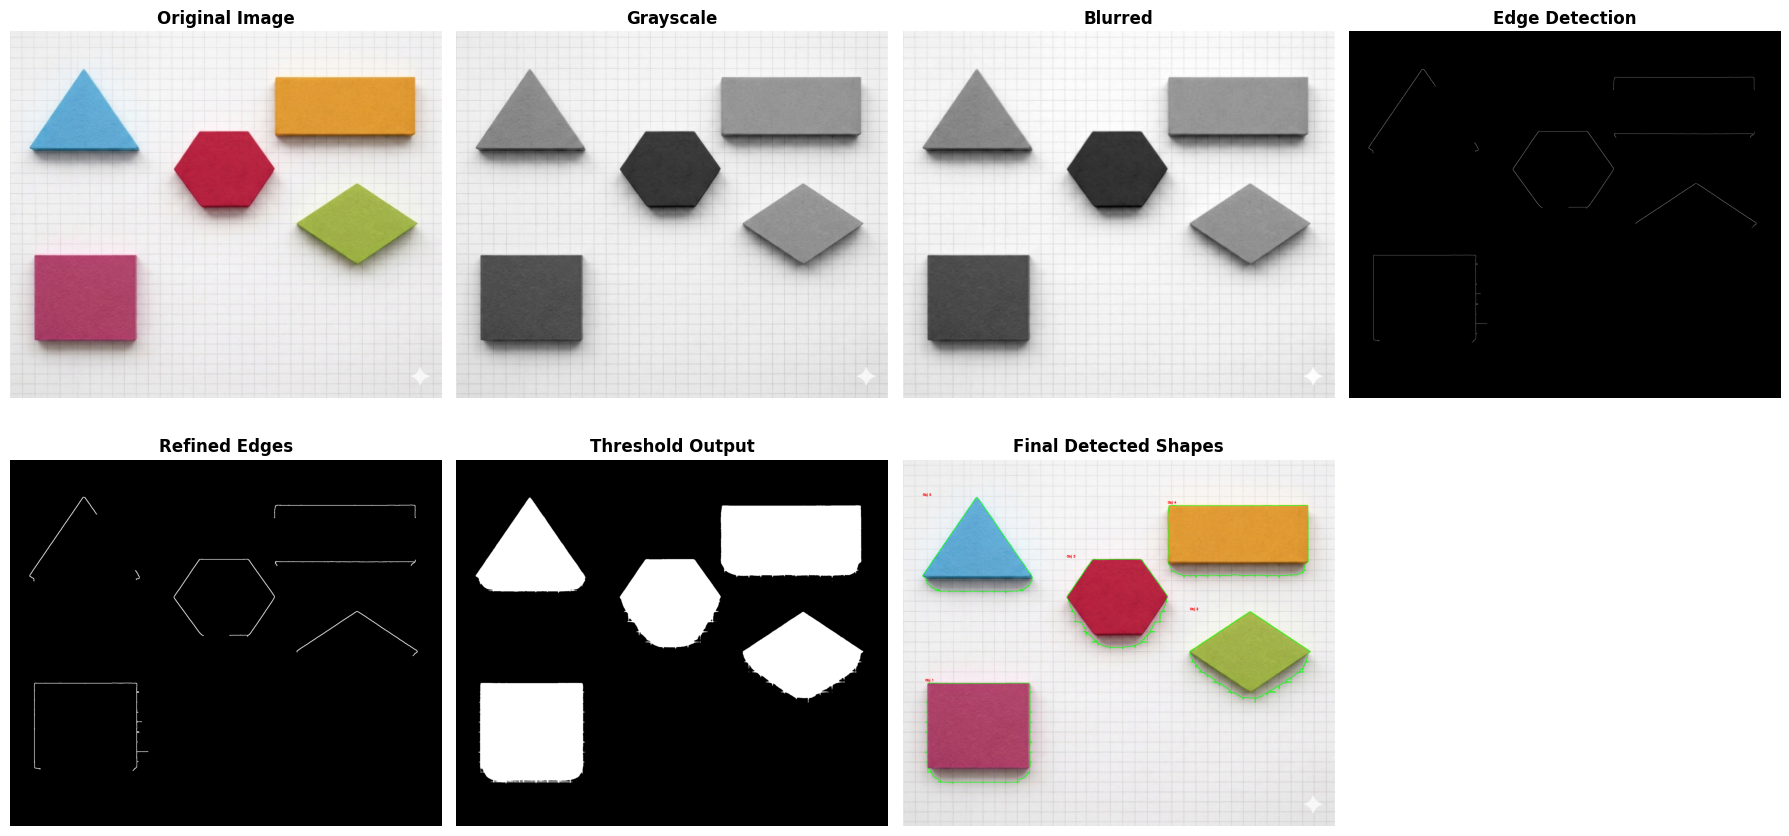

In [4]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("📤 Please select an image to upload:")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)
original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (7, 7), 0)

edges = cv2.Canny(blurred, 50, 150)

kernel = np.ones((3, 3), np.uint8)
refined_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
refined_edges = cv2.dilate(refined_edges, kernel, iterations=1)

_, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
min_area = 100
valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]
object_count = len(valid_contours)

final_image = original.copy()
for i, cnt in enumerate(valid_contours):
    cv2.drawContours(final_image, [cnt], -1, (0, 255, 0), 2)
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.putText(final_image, f"Obj {i+1}", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

print(f"\n{'='*50}")
print(f"OBJECT COUNTING & MEASUREMENT RESULTS")
print(f"{'='*50}")
print(f" Total Objects Detected: {object_count}\n")
for i, cnt in enumerate(valid_contours):
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    x, y, w, h = cv2.boundingRect(cnt)

    M = cv2.moments(cnt)
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
    else:
        cx, cy = 0, 0

    print(f"📦 Object {i+1:2d} | Area: {area:7.2f} px² | Perimeter: {perimeter:7.2f} px | BBox: {w}x{h} px | Centroid: ({cx}, {cy})")

titles = ['Original Image', 'Grayscale', 'Blurred', 'Edge Detection',
          'Refined Edges', 'Threshold Output', 'Final Detected Shapes']
images = [original, gray, blurred, edges, refined_edges, thresh, final_image]

plt.figure(figsize=(18, 9))
for i in range(len(images)):
    plt.subplot(2, 4, i+1)
    cmap = 'gray' if len(images[i].shape) == 2 else None
    plt.imshow(images[i], cmap=cmap)
    plt.title(titles[i], fontsize=12, fontweight='bold')
    plt.axis('off')
plt.tight_layout()
plt.show()